In [1]:
import sys
import json
import copy
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.lstm_dataset import LSTMDataset
from src.lstm_model import DrowsinessLSTM

In [2]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True


In [4]:
windows_df = pd.read_csv(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "windows.csv"
)

windows_df["subject"] = (
    windows_df["subject"]
    .astype(str)
    .str.zfill(2)
)

with open(
    PROJECT_ROOT
    / "processed"
    / "UTA"
    / "folds.json"
) as f:
    folds = json.load(f)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [5]:
all_dev = set()

for fold in folds:
    all_dev.update(fold["train_subjects"])
    all_dev.update(fold["val_subjects"])

print("Development subjects:", len(all_dev))
print(sorted(all_dev))

held_out = {
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
}

print("Overlap with held-out:", all_dev & held_out)

assert len(all_dev) == 38
assert len(all_dev & held_out) == 0

print("✅ Exactly 38 development subjects.")
print("✅ Held-out subjects are completely excluded.")

Development subjects: 38
['02', '03', '04', '05', '07', '08', '09', '10', '12', '13', '14', '15', '17', '18', '19', '20', '22', '23', '24', '25', '27', '28', '29', '30', '32', '33', '34', '35', '37', '38', '39', '40', '42', '43', '44', '45', '47', '48']
Overlap with held-out: set()
✅ Exactly 38 development subjects.
✅ Held-out subjects are completely excluded.


In [6]:
all_acc = []
all_f1 = []
all_low_f1 = []
all_reports = []

In [7]:
model = DrowsinessLSTM()
print(model)
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

DrowsinessLSTM(
  (lstm): LSTM(512, 64, num_layers=2, batch_first=True, dropout=0.5)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [8]:
TEST_SUBJECTS = {
    "01", "06", "11", "16", "21",
    "26", "31", "36", "41"
}

# Subjects used in this fold
train_subjects = set(fold["train_subjects"])
val_subjects = set(fold["val_subjects"])
used_subjects = train_subjects | val_subjects

print("Train subjects:", sorted(train_subjects))
print("Val subjects  :", sorted(val_subjects))
print("Total subjects in fold:", len(used_subjects))

# Verify no held-out subjects leaked in
overlap = used_subjects & TEST_SUBJECTS
print("Held-out overlap:", sorted(overlap))

assert len(overlap) == 0, (
    f"❌ Leakage detected in Fold {fold_idx+1}: {sorted(overlap)}"
)

# Verify we are only using development subjects
DEV_SUBJECTS = set()

for f in folds:
    DEV_SUBJECTS.update(f["train_subjects"])
    DEV_SUBJECTS.update(f["val_subjects"])

assert len(DEV_SUBJECTS) == 38, (
    f"Expected 38 development subjects, got {len(DEV_SUBJECTS)}"
)

assert used_subjects.issubset(DEV_SUBJECTS), (
    f"Fold {fold_idx+1} contains unexpected subjects."
)

print("✅ Fold uses only development subjects.")
print("✅ No held-out subjects present.")


for fold_idx, fold in enumerate(folds):

    torch.cuda.empty_cache()

    print("=" * 60)
    print(f"FOLD {fold_idx+1}")
    print("=" * 60)

    train_df = windows_df[
        windows_df["subject"].isin(
            fold["train_subjects"]
        )
    ]

    val_df = windows_df[
        windows_df["subject"].isin(
            fold["val_subjects"]
        )
    ]

    print("Train:", len(train_df))
    print("Val:", len(val_df))

    train_dataset = LSTMDataset(train_df)
    val_dataset = LSTMDataset(val_df)

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    model = DrowsinessLSTM().to(device)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.1
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-5
    )

    best_f1 = 0
    best_acc = 0
    best_low_f1 = 0
    counter = 0
    patience = 10
    best_report = None

    for epoch in range(50):

        print(f"\nEpoch {epoch+1}/50")

        ########################
        # TRAIN
        ########################

        model.train()

        train_preds = []
        train_labels = []

        for x, y in tqdm(train_loader):

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            preds = logits.argmax(1)

            train_preds.extend(
                preds.cpu().numpy()
            )

            train_labels.extend(
                y.cpu().numpy()
            )

        train_acc = accuracy_score(
            train_labels,
            train_preds
        )

        train_f1 = f1_score(
            train_labels,
            train_preds,
            average="macro"
        )

        ########################
        # VALIDATION
        ########################

        model.eval()

        val_preds = []
        val_labels = []

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)
                y = y.to(device)

                logits = model(x)

                preds = logits.argmax(1)

                val_preds.extend(
                    preds.cpu().numpy()
                )

                val_labels.extend(
                    y.cpu().numpy()
                )

        val_acc = accuracy_score(
            val_labels,
            val_preds
        )

        val_f1 = f1_score(
            val_labels,
            val_preds,
            average="macro"
        )

        report = classification_report(
            val_labels,
            val_preds,
            target_names=[
                "Alert",
                "Low Vigilant",
                "Drowsy"
            ],
            output_dict=True
        )

        low_f1 = report[
            "Low Vigilant"
        ]["f1-score"]

        print(
            f"Train Acc: {train_acc:.4f}"
        )
        print(
            f"Train F1: {train_f1:.4f}"
        )
        print(
            f"Val Acc: {val_acc:.4f}"
        )
        print(
            f"Val F1: {val_f1:.4f}"
        )
        print(
            f"Low Vigilant F1: {low_f1:.4f}"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1
            best_acc = val_acc
            best_low_f1 = low_f1
            best_report = report

            counter = 0

            torch.save(
                model.state_dict(),
                PROJECT_ROOT
                / "models"
                / f"lstm_fold_{fold_idx+1}.pth"
            )

            print("✅ Best model saved.")

        else:
            counter += 1
            print(
                f"No improvement ({counter}/{patience})"
            )

            if counter >= patience:
                print("Early stopping.")
                break

    print("\nFold Results")
    print(
        f"Accuracy: {best_acc:.4f}"
    )
    print(
        f"Macro F1: {best_f1:.4f}"
    )
    print(
        f"Low Vigilant F1: {best_low_f1:.4f}"
    )

    all_acc.append(best_acc)
    all_f1.append(best_f1)
    all_low_f1.append(best_low_f1)
    all_reports.append(best_report)

Train subjects: ['02', '03', '04', '05', '07', '08', '09', '12', '13', '15', '17', '18', '20', '22', '23', '25', '28', '30', '32', '33', '34', '35', '38', '39', '40', '42', '43', '44', '45', '47', '48']
Val subjects  : ['10', '14', '19', '24', '27', '29', '37']
Total subjects in fold: 38
Held-out overlap: []
✅ Fold uses only development subjects.
✅ No held-out subjects present.
FOLD 1
Train: 53118
Val: 14248



Epoch 1/50


  0%|          | 0/415 [00:00<?, ?it/s]

  0%|          | 1/415 [00:01<09:22,  1.36s/it]

  0%|          | 2/415 [00:01<05:03,  1.36it/s]

...

 99%|█████████▉| 422/427 [00:35<00:00, 11.94it/s]

 99%|█████████▉| 424/427 [00:35<00:00, 11.81it/s]

100%|█████████▉| 426/427 [00:36<00:00, 11.65it/s]

100%|██████████| 427/427 [00:36<00:00, 11.83it/s]

Train Acc: 1.0000
Train F1: 1.0000
Val Acc: 0.8130
Val F1: 0.8170
Low Vigilant F1: 0.8291
No improvement (10/10)
Early stopping.

Fold Results
Accuracy: 0.8211
Macro F1: 0.8260
Low Vigilant F1: 0.8466


In [9]:
import numpy as np
import pandas as pd

results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": all_acc,
    "Macro_F1": all_f1,
    "Low_Vigilant_F1": all_low_f1
})

print("=" * 60)
print("FOLD-WISE RESULTS")
print("=" * 60)
print(results)

FOLD-WISE RESULTS
   Fold  Accuracy  Macro_F1  Low_Vigilant_F1
0     1  0.910724  0.911899         0.937929
1     2  0.761494  0.754864         0.787453
2     3  0.832340  0.828673         0.808554
3     4  1.000000  1.000000         1.000000
4     5  0.821134  0.826048         0.846581


In [10]:
print("\n" + "=" * 60)
print("FINAL 5-FOLD RESULTS")
print("=" * 60)

print(
    f"Accuracy: {np.mean(all_acc):.4f} ± {np.std(all_acc):.4f}"
)

print(
    f"Macro F1: {np.mean(all_f1):.4f} ± {np.std(all_f1):.4f}"
)

print(
    f"Low Vigilant F1: "
    f"{np.mean(all_low_f1):.4f} ± {np.std(all_low_f1):.4f}"
)


FINAL 5-FOLD RESULTS
Accuracy: 0.8651 ± 0.0825
Macro F1: 0.8643 ± 0.0841
Low Vigilant F1: 0.8761 ± 0.0806


In [11]:
results.to_csv(
    PROJECT_ROOT / "results_5fold.csv",
    index=False
)

In [12]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Low_Vigilant_F1"
    ],
    "Mean": [
        np.mean(all_acc),
        np.mean(all_f1),
        np.mean(all_low_f1)
    ],
    "Std": [
        np.std(all_acc),
        np.std(all_f1),
        np.std(all_low_f1)
    ]
})

summary.to_csv(
    PROJECT_ROOT / "results_summary.csv",
    index=False
)

print("\n")
print(summary)



            Metric      Mean       Std
0         Accuracy  0.865139  0.082486
1         Macro_F1  0.864297  0.084130
2  Low_Vigilant_F1  0.876104  0.080581


In [13]:
results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": all_acc,
    "Macro_F1": all_f1,
    "Low_Vigilant_F1": all_low_f1
})

results.to_csv(
    PROJECT_ROOT / "results_5fold.csv",
    index=False
)

print(results)

   Fold  Accuracy  Macro_F1  Low_Vigilant_F1
0     1  0.910724  0.911899         0.937929
1     2  0.761494  0.754864         0.787453
2     3  0.832340  0.828673         0.808554
3     4  1.000000  1.000000         1.000000
4     5  0.821134  0.826048         0.846581


In [14]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro_F1",
        "Low_Vigilant_F1"
    ],
    "Mean": [
        np.mean(all_acc),
        np.mean(all_f1),
        np.mean(all_low_f1)
    ],
    "Std": [
        np.std(all_acc),
        np.std(all_f1),
        np.std(all_low_f1)
    ]
})

summary.to_csv(
    PROJECT_ROOT / "results_summary.csv",
    index=False
)

print(summary)

            Metric      Mean       Std
0         Accuracy  0.865139  0.082486
1         Macro_F1  0.864297  0.084130
2  Low_Vigilant_F1  0.876104  0.080581


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_cm = []

In [16]:
best_fold = np.argmax(all_f1)
print("Best fold:", best_fold + 1)

Best fold: 4


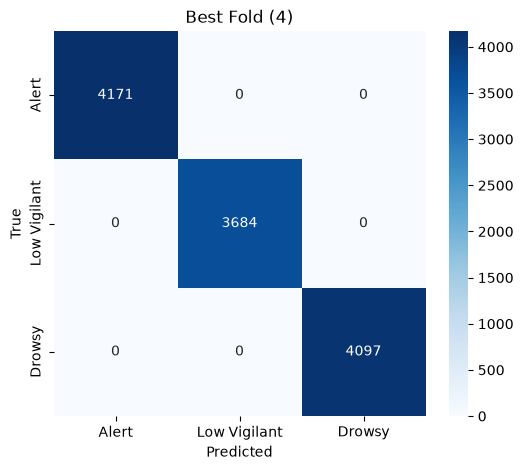

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fold = folds[best_fold]

val_df = windows_df[
    windows_df["subject"].isin(
        fold["val_subjects"]
    )
]

val_dataset = LSTMDataset(val_df)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

model = DrowsinessLSTM().to(device)
model.load_state_dict(
    torch.load(
        PROJECT_ROOT
        / "models"
        / f"lstm_fold_{best_fold+1}.pth",
        map_location=device
    )
)

model.eval()

val_preds = []
val_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        logits = model(x)
        preds = logits.argmax(1)

        val_preds.extend(preds.cpu().numpy())
        val_labels.extend(y.numpy())

cm = confusion_matrix(
    val_labels,
    val_preds
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    yticklabels=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ]
)

plt.title(
    f"Best Fold ({best_fold+1})"
)
plt.ylabel("True")
plt.xlabel("Predicted")

plt.savefig(
    PROJECT_ROOT
    / f"confusion_fold_{best_fold+1}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Low Vigilant F1"
    ],
    "Result": [
        f"{np.mean(all_acc)*100:.2f} ± {np.std(all_acc)*100:.2f}",
        f"{np.mean(all_f1)*100:.2f} ± {np.std(all_f1)*100:.2f}",
        f"{np.mean(all_low_f1)*100:.2f} ± {np.std(all_low_f1)*100:.2f}",
    ]
})

print(table)

table.to_csv(
    PROJECT_ROOT / "paper_results_table.csv",
    index=False
)

            Metric        Result
0         Accuracy  86.51 ± 8.25
1         Macro F1  86.43 ± 8.41
2  Low Vigilant F1  87.61 ± 8.06


In [19]:
import numpy as np
import pandas as pd

results = []

for i, report in enumerate(all_reports):

    results.append({
        "Fold": i + 1,
        "Accuracy": all_acc[i],
        "Macro_F1": all_f1[i],
        "Alert_F1": report["Alert"]["f1-score"],
        "Low_Vigilant_F1": report["Low Vigilant"]["f1-score"],
        "Drowsy_F1": report["Drowsy"]["f1-score"]
    })

results_df = pd.DataFrame(results)

# Add Mean and Std rows
mean_row = {
    "Fold": "Mean",
    "Accuracy": results_df["Accuracy"].mean(),
    "Macro_F1": results_df["Macro_F1"].mean(),
    "Alert_F1": results_df["Alert_F1"].mean(),
    "Low_Vigilant_F1": results_df["Low_Vigilant_F1"].mean(),
    "Drowsy_F1": results_df["Drowsy_F1"].mean()
}

std_row = {
    "Fold": "Std",
    "Accuracy": results_df["Accuracy"].std(),
    "Macro_F1": results_df["Macro_F1"].std(),
    "Alert_F1": results_df["Alert_F1"].std(),
    "Low_Vigilant_F1": results_df["Low_Vigilant_F1"].std(),
    "Drowsy_F1": results_df["Drowsy_F1"].std()
}

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([mean_row, std_row])
    ],
    ignore_index=True
)

print(results_df)

results_df.to_csv(
    PROJECT_ROOT / "paper_table_results.csv",
    index=False
)

   Fold  Accuracy  Macro_F1  Alert_F1  Low_Vigilant_F1  Drowsy_F1
0     1  0.910724  0.911899  0.892921         0.937929   0.904846
1     2  0.761494  0.754864  0.782861         0.787453   0.694277
2     3  0.832340  0.828673  0.892695         0.808554   0.784769
3     4  1.000000  1.000000  1.000000         1.000000   1.000000
4     5  0.821134  0.826048  0.789527         0.846581   0.842035
5  Mean  0.865139  0.864297  0.871601         0.876104   0.845186
6   Std  0.092223  0.094060  0.089438         0.090092   0.116147


In [20]:
with open(
    PROJECT_ROOT / "processed" / "UTA" / "folds.json"
) as f:
    folds = json.load(f)

for i, fold in enumerate(folds, start=1):
    print(f"\nFold {i}")
    print("Train:", len(fold["train_subjects"]))
    print("Val:", len(fold["val_subjects"]))


Fold 1
Train: 30
Val: 8

Fold 2
Train: 30
Val: 8

Fold 3
Train: 30
Val: 8

Fold 4
Train: 31
Val: 7

Fold 5
Train: 31
Val: 7


In [21]:
from pathlib import Path
import datetime

model_dir = PROJECT_ROOT / "models"

for p in sorted(model_dir.glob("lstm_fold_*.pth")):
    print(
        p.name,
        datetime.datetime.fromtimestamp(
            p.stat().st_mtime
        )
    )

lstm_fold_1.pth 2026-07-06 08:09:35.193239
lstm_fold_2.pth 2026-07-06 08:34:55.734437
lstm_fold_3.pth 2026-07-06 08:57:28.245648
lstm_fold_4.pth 2026-07-06 09:16:18.738989
lstm_fold_5.pth 2026-07-06 09:58:05.125573


In [22]:
import pandas as pd

print(pd.read_csv(PROJECT_ROOT / "results_5fold.csv"))
print()
print(pd.read_csv(PROJECT_ROOT / "results_summary.csv"))
print()
print(pd.read_csv(PROJECT_ROOT / "paper_table_results.csv"))

   Fold  Accuracy  Macro_F1  Low_Vigilant_F1
0     1  0.910724  0.911899         0.937929
1     2  0.761494  0.754864         0.787453
2     3  0.832340  0.828673         0.808554
3     4  1.000000  1.000000         1.000000
4     5  0.821134  0.826048         0.846581

            Metric      Mean       Std
0         Accuracy  0.865139  0.082486
1         Macro_F1  0.864297  0.084130
2  Low_Vigilant_F1  0.876104  0.080581

   Fold  Accuracy  Macro_F1  Alert_F1  Low_Vigilant_F1  Drowsy_F1
0     1  0.910724  0.911899  0.892921         0.937929   0.904846
1     2  0.761494  0.754864  0.782861         0.787453   0.694277
2     3  0.832340  0.828673  0.892695         0.808554   0.784769
3     4  1.000000  1.000000  1.000000         1.000000   1.000000
4     5  0.821134  0.826048  0.789527         0.846581   0.842035
5  Mean  0.865139  0.864297  0.871601         0.876104   0.845186
6   Std  0.092223  0.094060  0.089438         0.090092   0.116147


In [23]:
import shutil
from pathlib import Path

backup_dir = PROJECT_ROOT / "final_results_backup"
backup_dir.mkdir(exist_ok=True)

files = [
    "results_5fold.csv",
    "results_summary.csv",
    "paper_results_table.csv",
    "paper_table_results.csv",
]

for f in files:
    src = PROJECT_ROOT / f
    if src.exists():
        shutil.copy(src, backup_dir / f)

for p in (PROJECT_ROOT / "models").glob("lstm_fold_*.pth"):
    shutil.copy(p, backup_dir / p.name)

print("✅ Backup created:", backup_dir)

✅ Backup created: C:\Users\clark\OneDrive\Desktop\drowsiness_project\final_results_backup


In [24]:
from sklearn.metrics import classification_report
import pandas as pd

# Classification report as dictionary
report = classification_report(
    val_labels,
    val_preds,
    target_names=[
        "Alert",
        "Low Vigilant",
        "Drowsy"
    ],
    digits=4,
    output_dict=True
)

# Convert to DataFrame
report_df = pd.DataFrame(report).transpose()

print(report_df)

# Save as CSV
report_df.to_csv(
    PROJECT_ROOT
    / f"classification_report_fold_{best_fold+1}.csv"
)

print(
    f"✅ Saved: classification_report_fold_{best_fold+1}.csv"
)

              precision  recall  f1-score  support
Alert               1.0     1.0       1.0   4171.0
Low Vigilant        1.0     1.0       1.0   3684.0
Drowsy              1.0     1.0       1.0   4097.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0  11952.0
weighted avg        1.0     1.0       1.0  11952.0
✅ Saved: classification_report_fold_4.csv
